# Handlers Demo

This notebook demonstrates the two main output handlers provided by `axikernels`:

- **`StationOutput`** — reads the NetCDF station waveforms written by AxiSEM3D and exposes them as ObsPy streams and inventories. It can also *obspyfy* the data, converting it into standard ObsPy-compatible files (miniSEED + StationXML + QuakeML) so you can use the full ObsPy ecosystem from that point on.
- **`ElementOutput`** — reads the full wavefield stored at element GLL points and interpolates it at any requested [radius, lat, lon] coordinate.

**Prerequisites:** run `bash run.sh` first to populate `sim_run/output/`.

In [ ]:
from axikernels.core.handlers import station_output, element_output
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

## StationOutput

`StationOutput` wraps the per-rank NetCDF files written by AxiSEM3D into a single object. It auto-discovers all rank files in the directory and merges them transparently. The `.outputs` attribute lists the available waveform data groups.

In [ ]:
st_out = station_output.StationOutput('sim_run/output/stations/GSN_Station_Grid')

In [ ]:
st_out.outputs

{'elements': {'inner_core': {'path': '/home/adrian/PhD/AxiSEM3D/AxiSEM3D_Kernels/examples/handlers_demo/sim_run/output/elements/inner_core',
   'obspyfied': None},
  'outer_core': {'path': '/home/adrian/PhD/AxiSEM3D/AxiSEM3D_Kernels/examples/handlers_demo/sim_run/output/elements/outer_core',
   'obspyfied': None},
  'mantle': {'path': '/home/adrian/PhD/AxiSEM3D/AxiSEM3D_Kernels/examples/handlers_demo/sim_run/output/elements/mantle',
   'obspyfied': None}},
 'stations': {'GSN_Station_Grid': {'path': '/home/adrian/PhD/AxiSEM3D/AxiSEM3D_Kernels/examples/handlers_demo/sim_run/output/stations/GSN_Station_Grid',
   'obspyfied': {'path': '/home/adrian/PhD/AxiSEM3D/AxiSEM3D_Kernels/examples/handlers_demo/sim_run/output/stations/GSN_Station_Grid/obspyfied',
    'mseed': ['/home/adrian/PhD/AxiSEM3D/AxiSEM3D_Kernels/examples/handlers_demo/sim_run/output/stations/GSN_Station_Grid/obspyfied/GSN_Station_Grid.mseed'],
    'inventory': ['/home/adrian/PhD/AxiSEM3D/AxiSEM3D_Kernels/examples/handlers_dem

Use `.stream()` to load waveforms for a specific network/station/channel combination as an ObsPy `Stream`. AxiSEM3D performs the Lagrange/Fourier interpolation at station locations during the simulation itself, so the data here is already the final time series — ready for processing or plotting.

1 Trace(s) in Stream:
II.AAK..UZ | 1969-12-31T23:58:57.337500Z - 1970-01-01T00:29:58.831500Z | 0.6 Hz, 1115 samples


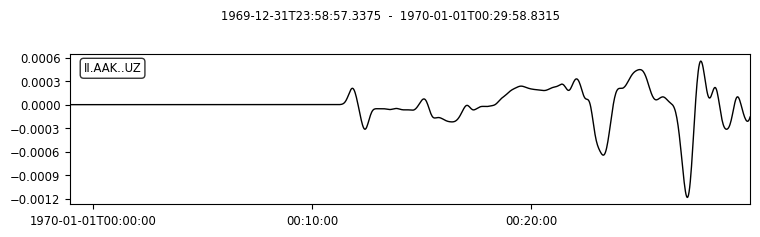

In [ ]:
data = st_out.stream(networks=['II'], station_names=['AAK'], locations=[''], channels=['UZ'])
print(data)
data.plot()
plt.show()

### Obspyfying the output

`.obspyfy()` converts the entire station output into standard ObsPy-compatible files stored in a new `obspyfied/` subdirectory:

- `waveforms.mseed` — all channels as miniSEED
- `inventory.xml` — station metadata as StationXML
- `catalogue.xml` — source info as QuakeML

Once obspyfied, you can reload the data with `ObspyfiedOutput` (or plain ObsPy) and work with it completely independently of the original simulation files.

In [ ]:
st_out.obspyfy()

Load the obspyfied output with `ObspyfiedOutput`. From here you have a standard ObsPy `Stream` — you can filter, taper, deconvolve instrument response, or use any other ObsPy processing tool.

3 Trace(s) in Stream:
II.AAK..UR | 1969-12-31T23:58:57.337500Z - 1970-01-01T00:29:58.831500Z | 0.6 Hz, 1115 samples
II.AAK..UT | 1969-12-31T23:58:57.337500Z - 1970-01-01T00:29:58.831500Z | 0.6 Hz, 1115 samples
II.AAK..UZ | 1969-12-31T23:58:57.337500Z - 1970-01-01T00:29:58.831500Z | 0.6 Hz, 1115 samples


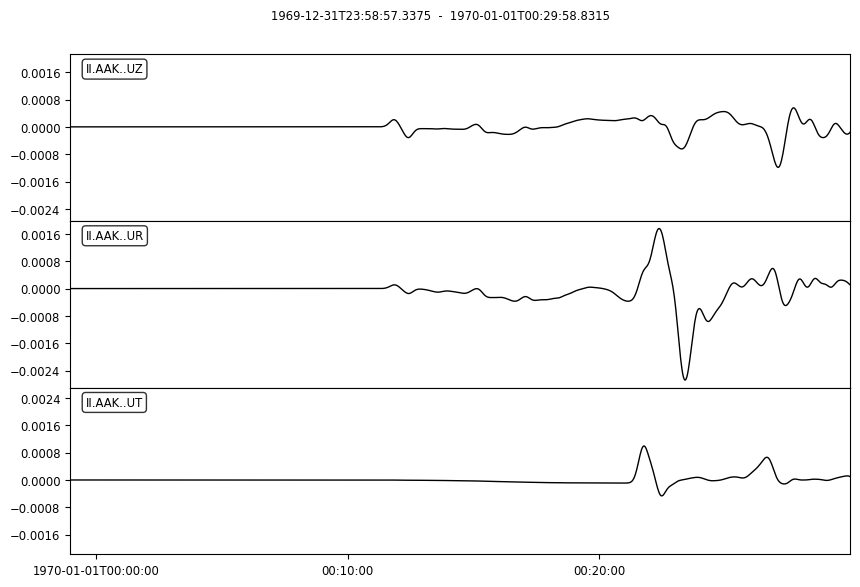

In [ ]:
from axikernels.core.handlers import obspy_output

obspyfied = obspy_output.ObspyfiedOutput(
    obspyfied_path='sim_run/output/stations/GSN_Station_Grid/obspyfied'
)

# Preview a single station so the plot stays compact
preview_stream = obspyfied.stream.select(network='II', station='AAK')
print(preview_stream)
preview_stream.plot(size=(900, 600))
plt.show()

## ElementOutput

`ElementOutput` gives access to the full wavefield recorded at GLL points across the mesh. Unlike station output, it is not tied to any pre-specified receiver locations — you can interpolate at *any* point in the domain after the simulation.

The constructor takes the path to the `elements/` directory; it auto-discovers subdirectories for each element group (`mantle`, `outer_core`, `inner_core`). The `.catalogue` attribute shows the source information.

In [ ]:
el_out = element_output.ElementOutput(path_to_element_output='sim_run/output/elements')

In [ ]:
el_out.catalogue

1 Event(s) in Catalog:
1970-01-01T00:00:00.000000Z |  +0.000,   +0.000 | manual

`.load_data()` takes a point as `[radius_m, lat_deg, lon_deg]` and a list of channels, and returns the interpolated time series as a NumPy array. `.stream()` does the same but wraps the result in an ObsPy `Stream`.

Loading and interpolating: 100%|██████████| 1/1 [00:00<00:00, 204.01point/s]


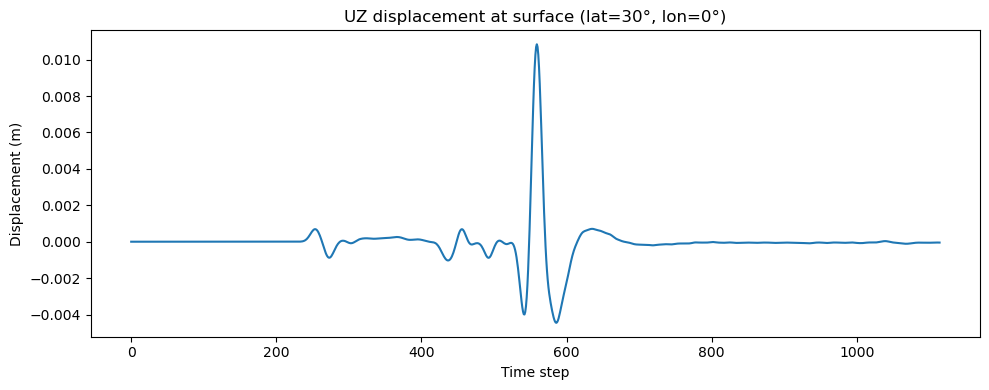

In [ ]:
# Point at surface: [radius_m, lat_deg, lon_deg]
point = np.array([6371000, 30.0, 0.0])
wavedata = el_out.load_data(point, channels=['UZ'])
plt.figure(figsize=(10, 4))
plt.plot(wavedata[0][0])
plt.title('UZ displacement at surface (lat=30°, lon=0°)')
plt.xlabel('Time step')
plt.ylabel('Displacement (m)')
plt.tight_layout()
plt.show()

Loading and interpolating: 100%|██████████| 1/1 [00:00<00:00, 291.21point/s]


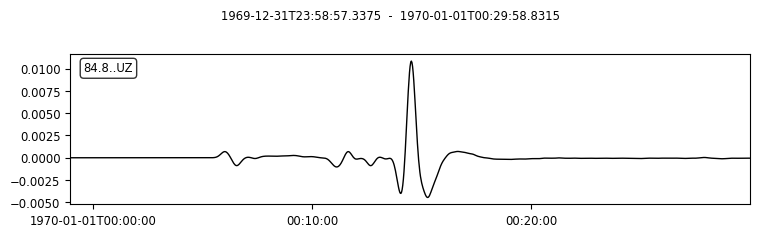

In [ ]:
stream = el_out.stream(points=point, channels=['UZ'])
stream.plot()
plt.show()